In [ ]:
import os
import sys

# Controlla se il notebook sta girando su Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    # Monta il drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Inserisci qui il percorso esatto della cartella su Drive.
    # Se è una cartella condivisa standard di cui avete creato una scorciatoia 
    # nel vostro Drive personale, il percorso sarà simile a questo:
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
    
    # Se invece è un "Drive Condiviso" aziendale/universitario:
    # BASE_PATH = '/content/drive/Shareddrives/Nome_Drive/Nome_Progetto/'

else:
    print("Ambiente locale rilevato.")
    # Imposta la directory base in locale. 
    # './' significa la cartella in cui si trova attualmente il notebook.
    # Oppure usa '../' se i notebook sono in una sottocartella e i dati fuori.
    BASE_PATH = '../'

print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
../


#### Import e Configurazione

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

I0000 00:00:1780948503.897519    4285 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780948504.921772    4285 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780948508.982896    4285 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:

# --- CONFIGURAZIONE ---

# Ora costruisci i percorsi dei file unendo il BASE_PATH al resto
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed.csv', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed.csv', 'metadata', "val.csv")

IMG_SIZE = (512, 512)
BATCH_SIZE = 8
SEED = 42

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Cartella per salvare i modelli
OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260608_baseline_resnet50_fine_tuned')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)
print(OUTPUT_DIR)

../data/processed.csv/metadata/all_processed.csv
../experiments/exp20260608_baseline_resnet50_fine_tuned


#### Preparazione Dati e Pipeline

Filtriamo il dataset per usare solo i dati reali di train e validation. Includiamo la funzione aggiornata con l'aggiunta del rumore gaussiano per la data augmentation.

In [ ]:
# 1. Carica e filtra il CSV
df_train = pd.read_csv(TRAIN_CSV_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

# 2. Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

# 3. Funzioni tf.data (con rumore gaussiano per augmentation)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
        
    return img, tf.cast(label, tf.float32)

def make_dataset(df, shuffle=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, shuffle=True)
val_ds = make_dataset(df_val, shuffle=False)

Class Weights: {0: 0.5999412110523221, 1: 3.001470588235294}


#### Costruzione dell'Architettura ResNet-50

Creiamo la funzione che istanzia il modello. Inizialmente, congeliamo tutto il backbone (ResNet-50) per addestrare solo la nostra testina di classificazione (custom head).

In [25]:
def build_base_model():
    # Carica il backbone ResNet-50 pre-addestrato
    base_model = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(512, 512, 3)
    )
    
    # Congela il backbone per la Fase 1
    base_model.trainable = False
    
    # Costruisci l'architettura completa
    inputs = keras.Input(shape=(512, 512, 3))
    
    # training=False è fondamentale qui per la Batch Normalization
    x = base_model(inputs, training=False) 
    
    # Global Average Pooling (scelta ottimale per ridurre i parametri)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Custom Head con LeakyReLU
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.1)(x) # alpha è la pendenza per i valori negativi
    x = layers.Dropout(0.5)(x)
    
    # Output binario (1 neurone con sigmoid)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_base_model()
model.summary()

/home/enzo/tf-gpu/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#### Fase 1: Addestramento Custom Head

In [26]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall')
    ]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max'),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'baseline_fase1_best.keras'), monitor='val_auc', save_best_only=True, mode='max')
]

history_phase1 = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase1
)

Epoch 1/15


I0000 00:00:1780952277.957146    4458 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152996__.187


256/256 ━━━━━━━━━━━━━━━━━━━━ 78s 207ms/step - accuracy: 0.4998 - auc: 0.5098 - loss: 1.1414 - recall: 0.4971 - val_accuracy: 0.1670 - val_auc: 0.6047 - val_loss: 1.1069 - val_recall: 1.0000
Epoch 2/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - accuracy: 0.5287 - auc: 0.5437 - loss: 0.7580 - recall: 0.5500 - val_accuracy: 0.2037 - val_auc: 0.6021 - val_loss: 0.9861 - val_recall: 1.0000
Epoch 3/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.5066 - auc: 0.5258 - loss: 0.7623 - recall: 0.5294 - val_accuracy: 0.6934 - val_auc: 0.5890 - val_loss: 0.5694 - val_recall: 0.3425
Epoch 4/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 30s 116ms/step - accuracy: 0.5017 - auc: 0.5203 - loss: 0.7726 - recall: 0.5235 - val_accuracy: 0.7391 - val_auc: 0.5936 - val_loss: 0.5635 - val_recall: 0.3014
Epoch 5/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 30s 116ms/step - accuracy: 0.5287 - auc: 0.5451 - loss: 0.7468 - recall: 0.5559 - val_accuracy: 0.4371 - val_auc: 0.6255 - val_loss: 0.7310 - val_recall: 0.8219
Epoch 

#### Fase 2: Fine Tuning

In [27]:
# Scongela l'intero modello base
base_model.trainable = True

# Ricongela i layer inferiori, lasciando allenabili solo gli ultimi 30
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Ricontrolla i layer allenabili
print(f"Totale layer nel base_model: {len(base_model.layers)}")
print(f"Layer addestrabili: {len(model.trainable_variables)}")

# Ricompila il modello con un Learning Rate MOLTO basso (fondamentale!)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall')
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max'),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'baseline_final_best.keras'), monitor='val_auc', save_best_only=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {OUTPUT_DIR}baseline_final_best.keras")

Totale layer nel base_model: 175
Layer addestrabili: 16
Epoch 1/30


I0000 00:00:1780952726.638887    4458 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_196244__.199


256/256 ━━━━━━━━━━━━━━━━━━━━ 80s 201ms/step - accuracy: 0.6110 - auc: 0.6042 - loss: 0.6879 - recall: 0.5029 - val_accuracy: 0.6842 - val_auc: 0.6312 - val_loss: 0.6340 - val_recall: 0.4521 - learning_rate: 1.0000e-05
Epoch 2/30


W0000 00:00:1780952784.858355   17439 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554752 bytes after encountering the first element of size 33554752 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.6183 - auc: 0.6426 - loss: 0.6582 - recall: 0.5735 - val_accuracy: 0.5378 - val_auc: 0.6268 - val_loss: 0.7401 - val_recall: 0.6575 - learning_rate: 1.0000e-05
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 30s 116ms/step - accuracy: 0.6516 - auc: 0.6927 - loss: 0.6294 - recall: 0.6118 - val_accuracy: 0.4142 - val_auc: 0.6458 - val_loss: 0.8202 - val_recall: 0.8082 - learning_rate: 1.0000e-05
Epoch 4/30


W0000 00:00:1780952842.136734   17439 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554752 bytes after encountering the first element of size 33554752 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


256/256 ━━━━━━━━━━━━━━━━━━━━ 29s 112ms/step - accuracy: 0.6923 - auc: 0.7627 - loss: 0.5803 - recall: 0.6618 - val_accuracy: 0.6568 - val_auc: 0.6518 - val_loss: 0.6237 - val_recall: 0.5342 - learning_rate: 1.0000e-05
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.7099 - auc: 0.7735 - loss: 0.5678 - recall: 0.6647 - val_accuracy: 0.6339 - val_auc: 0.6386 - val_loss: 0.6074 - val_recall: 0.5068 - learning_rate: 1.0000e-05
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 29s 111ms/step - accuracy: 0.7168 - auc: 0.8065 - loss: 0.5420 - recall: 0.7412 - val_accuracy: 0.6407 - val_auc: 0.6522 - val_loss: 0.6660 - val_recall: 0.5753 - learning_rate: 1.0000e-05
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.7673 - auc: 0.8419 - loss: 0.5024 - recall: 0.7412 - val_accuracy: 0.7300 - val_auc: 0.6488 - val_loss: 0.5758 - val_recall: 0.4247 - learning_rate: 1.0000e-05
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - accuracy: 0.7496 - auc: 0.8466 - loss:

Analisi Overfitting - Fase 2 (Fine Tuning):


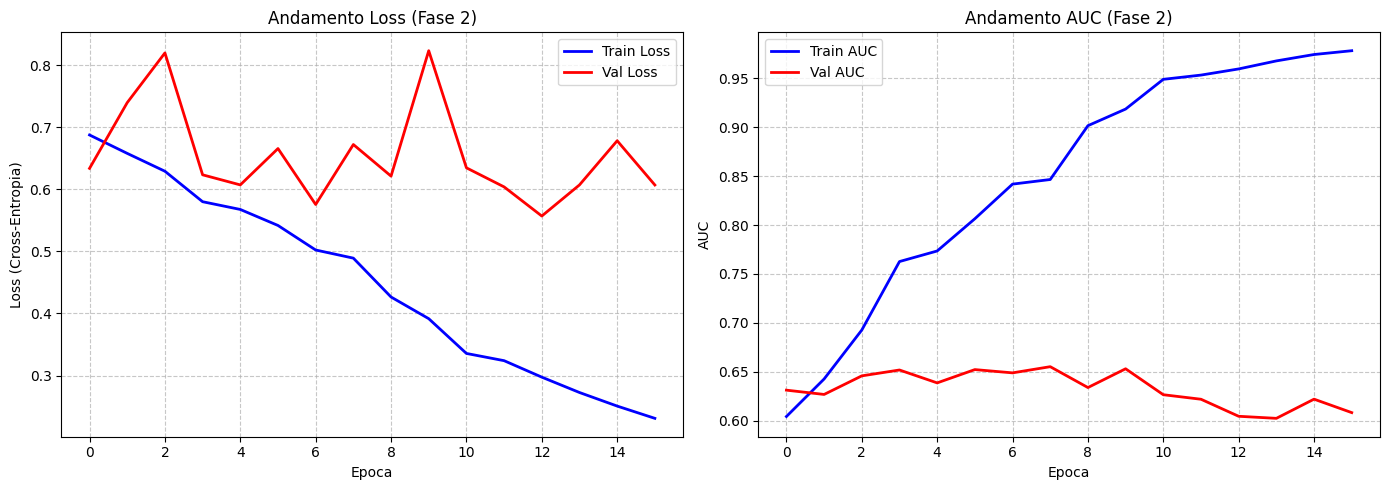

In [28]:
def plot_training_history(history, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafico della Loss (Ricerca la divergenza a "forbice")
    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss (Cross-Entropia)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Grafico dell'AUC (Ricerca il divario tra train e val)
    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Tracciamo le curve della fase di fine-tuning
print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(history_phase2, "(Fase 2)")